In [ ]:
!apt-get update -qq && apt-get install -y ffmpeg

Path to dataset files: /root/.cache/kagglehub/datasets/gauravpendharkar/blended-malware-image-dataset/versions/1
malware_dataset directory structure: ['train', 'val']
Train directory exists: /root/.cache/kagglehub/datasets/gauravpendharkar/blended-malware-image-dataset/versions/1/malware_dataset/train
Validation directory exists: /root/.cache/kagglehub/datasets/gauravpendharkar/blended-malware-image-dataset/versions/1/malware_dataset/val
Training data shape: (7894, 4096)
Testing data shape: (1974, 4096)
Accuracy: 0.8900709219858156
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        70
           1       0.84      0.75      0.79        68
           2       0.93      0.89      0.91        74
           3       0.91      0.97      0.94        32
           4       0.96      0.93      0.94        73
           5       0.79      0.69      0.74        75
           6       0.88      0.79      0.83        62
     

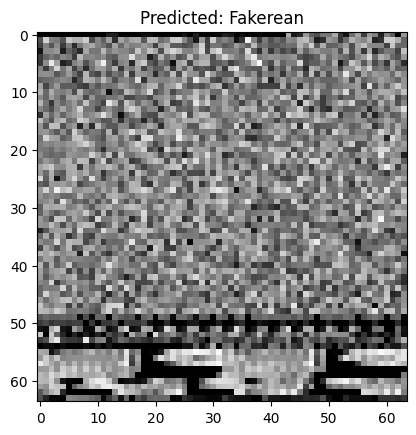

In [ ]:
!pip install numpy pandas scikit-learn matplotlib tensorflow keras opencv-python
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report

# Download the dataset using kagglehub
path = kagglehub.dataset_download("gauravpendharkar/blended-malware-image-dataset")

print("Path to dataset files:", path)

# List the directory structure of the 'malware_dataset' directory
malware_dataset_dir = os.path.join(path, 'malware_dataset')
print("malware_dataset directory structure:", os.listdir(malware_dataset_dir))

# Check for the 'train' and 'val' directories within 'malware_dataset'
train_dir = os.path.join(malware_dataset_dir, 'train')
val_dir = os.path.join(malware_dataset_dir, 'val')

# Verify if the 'train' directory exists
if os.path.exists(train_dir):
    print(f"Train directory exists: {train_dir}")
else:
    print(f"Train directory does NOT exist: {train_dir}")

# Verify if the 'val' directory exists
if os.path.exists(val_dir):
    print(f"Validation directory exists: {val_dir}")
else:
    print(f"Validation directory does NOT exist: {val_dir}")

# If the directories exist, proceed with loading the data
if os.path.exists(train_dir):
    images = []
    labels = []

    for label in os.listdir(train_dir):
        label_folder = os.path.join(train_dir, label)
        if os.path.isdir(label_folder):
            for image_file in os.listdir(label_folder):
                image_path = os.path.join(label_folder, image_file)
                # Read and resize image (e.g., resize to 64x64)
                img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                img_resized = cv2.resize(img, (64, 64))  # Resize to 64x64 for simplicity
                images.append(img_resized.flatten())  # Flatten the image to 1D array
                labels.append(label)

    # Convert to numpy arrays
    inputs = np.array(images)
    labels = np.array(labels)

    # Normalize the image data (scaling pixel values between 0 and 1)
    inputs = inputs / 255.0

    # Convert labels to numeric values using LabelEncoder
    label_encoder = LabelEncoder()
    labels_encoded = label_encoder.fit_transform(labels)

    # Convert labels to categorical format for classification (one-hot encoding)
    labels_one_hot = to_categorical(labels_encoded)

    # Split the data into training and testing sets
    inputs_train, inputs_test, labels_train, labels_test = train_test_split(inputs, labels_one_hot, test_size=0.2, random_state=42)

    # Print the shape of the data
    print("Training data shape:", inputs_train.shape)
    print("Testing data shape:", inputs_test.shape)

    # Train a simple MLP model (you can also try a deeper architecture)
    from sklearn.neural_network import MLPClassifier

    mlp_model = MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42)
    mlp_model.fit(inputs_train, np.argmax(labels_train, axis=1))  # Use argmax to convert one-hot labels to integers

    # Evaluate the model on the test set
    predictions = mlp_model.predict(inputs_test)

    # Convert predictions back to categorical
    print("Accuracy:", accuracy_score(np.argmax(labels_test, axis=1), predictions))
    print("Classification Report:\n", classification_report(np.argmax(labels_test, axis=1), predictions))

    # If you want to visualize an example image from the test set
    plt.imshow(inputs_test[0].reshape(64, 64), cmap='gray')
    plt.title(f"Predicted: {label_encoder.inverse_transform([predictions[0]])[0]}")
    plt.show()
else:
    print("Train directory not found. Please check the structure of the dataset.")
